# Chapter 14 Bayesian Ab Testing: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-14-bayesian-ab-testing-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

In [1]:
"""
Interactive figures for Chapter 14: Bayesian Experimentation for A/B Testing (Part 3).

Same pattern as prior chapters: each function builds one self-contained, standalone Plotly
HTML page and writes it to ../_generated/. Run directly to regenerate every figure:
    python3 chapter-14-bayesian-ab-testing-plots.py

Every FIGURES key below matches an iframe src embedded in chapter-14-bayesian-ab-testing.md.
Keep it that way: a key here with no matching iframe in the chapter is a figure the reader
never sees; an iframe in the chapter with no key here is a figure that quietly disappears the
next time this script runs from a clean _generated/.
"""

import os

import numpy as np
import plotly.graph_objects as go
from scipy import stats

RNG = np.random.default_rng(101)
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(＿_file_＿)), "..", "_generated")
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
def save(fig: go.Figure, name: str) -> str:
    path = os.path.join(OUT_DIR, f"{name}.html")
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return path


In [3]:


# ---------------------------------------------------------------------------
# Figure 1: Beta priors, from uninformative to strongly informative
# ---------------------------------------------------------------------------
def fig_prior_shapes() -> go.Figure:
    priors = [(1, 1), (11, 91), (50, 450), (200, 1800), (1000, 9000)]
    labels = ["Beta(1,1) uninformative", "Beta(11,91) weakly informative (~100 obs.)",
              "Beta(50,450) more confident (~500 obs.)",
              "Beta(200,1800) strongly informative (~2,000 obs.)",
              "Beta(1000,9000) highly informative (~10,000 obs.)"]
    x = np.linspace(0, 0.4, 400)
    x_list = x.tolist()
    frames = []
    for (a, b), label in zip(priors, labels):
        pdf = stats.beta.pdf(x, a, b)
        frames.append(
            go.Frame(
                name=label,
                data=[go.Scatter(x=x_list, y=pdf.tolist(), mode="lines", fill="tozeroy",
                                  line=dict(color="#4C78A8", width=2.5))],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=f"mean = {a / (a + b):.1%}, pseudo-observations = {a + b - 2:.0f}",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A prior expresses the same 10% central belief at five different strengths",
        xaxis_title="conversion rate",
        yaxis_title="density",
        xaxis_range=[0, 0.4],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "prior: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [4]:


# ---------------------------------------------------------------------------
# Figure 2: a single variant's posterior narrowing as data accumulates
# ---------------------------------------------------------------------------
def fig_posterior_update() -> go.Figure:
    prior_a, prior_b = 1, 1
    true_rate = 0.10
    sample_sizes = [0, 25, 100, 500, 2000, 8000]
    x = np.linspace(0, 0.4, 400)
    x_list = x.tolist()
    frames = []
    for n in sample_sizes:
        conv = RNG.binomial(n, true_rate) if n else 0
        a, b = prior_a + conv, prior_b + (n - conv)
        mean = a / (a + b)
        frames.append(
            go.Frame(
                name=str(n),
                data=[go.Scatter(x=x_list, y=stats.beta.pdf(x, a, b).tolist(), mode="lines",
                                  fill="tozeroy", line=dict(color="#4C78A8", width=3))],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=(f"n = {n}, conversions = {conv}<br>"
                          f"posterior mean = {mean:.1%}"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A single variant's Beta(1,1) posterior narrows and settles as visitors accumulate",
        xaxis_title="conversion rate",
        yaxis_title="density",
        xaxis_range=[0, 0.4],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "visitors observed: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [5]:


# ---------------------------------------------------------------------------
# Figure 3: Variant A and Variant B posteriors separating as each collects data
# ---------------------------------------------------------------------------
def fig_ab_overlay() -> go.Figure:
    prior_a, prior_b = 1, 1
    true_a_rate, true_b_rate = 0.10, 0.125
    sample_sizes = [50, 200, 1000, 5000]
    x = np.linspace(0, 0.3, 400)
    x_list = x.tolist()
    frames = []
    for n in sample_sizes:
        a_conv = RNG.binomial(n, true_a_rate)
        b_conv = RNG.binomial(n, true_b_rate)
        aa, ab = prior_a + a_conv, prior_b + (n - a_conv)
        ba, bb = prior_a + b_conv, prior_b + (n - b_conv)
        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=x_list, y=stats.beta.pdf(x, aa, ab).tolist(), mode="lines",
                               name="Variant A posterior", line=dict(color="#4C78A8", width=3)),
                    go.Scatter(x=x_list, y=stats.beta.pdf(x, ba, bb).tolist(), mode="lines",
                               name="Variant B posterior", line=dict(color="#E45756", width=3)),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=f"A: {a_conv}/{n} conversions, B: {b_conv}/{n} conversions",
                    font=dict(size=12, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Variant A and Variant B posteriors separate as each group collects data",
        xaxis_title="conversion rate",
        yaxis_title="density",
        xaxis_range=[0, 0.3],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "visitors per variant: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [6]:


# ---------------------------------------------------------------------------
# Figure 4: win probability and expected loss as sample size grows
# ---------------------------------------------------------------------------
def fig_decision_metrics() -> go.Figure:
    prior_a, prior_b = 1, 1
    true_a_rate, true_b_rate = 0.10, 0.125
    sample_sizes = [50, 200, 500, 1000, 2000, 5000]
    n_samples = 200_000
    x = np.linspace(0, 0.3, 400)
    x_list = x.tolist()
    frames = []
    for n in sample_sizes:
        a_conv = RNG.binomial(n, true_a_rate)
        b_conv = RNG.binomial(n, true_b_rate)
        aa, ab = prior_a + a_conv, prior_b + (n - a_conv)
        ba, bb = prior_a + b_conv, prior_b + (n - b_conv)

        a_draws = RNG.beta(aa, ab, size=n_samples)
        b_draws = RNG.beta(ba, bb, size=n_samples)
        p_b_best = float(np.mean(b_draws > a_draws))
        expected_loss_b = float(np.mean(np.maximum(a_draws - b_draws, 0)))

        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=x_list, y=stats.beta.pdf(x, aa, ab).tolist(), mode="lines",
                               name="Variant A posterior", line=dict(color="#4C78A8", width=2)),
                    go.Scatter(x=x_list, y=stats.beta.pdf(x, ba, bb).tolist(), mode="lines",
                               name="Variant B posterior", line=dict(color="#E45756", width=2)),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=(f"A: {a_conv}/{n}, B: {b_conv}/{n}<br>"
                          f"P(B beats A) = {p_b_best:.1%}<br>"
                          f"expected loss choosing B = {expected_loss_b:.4f}"),
                    font=dict(size=12, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Win probability and expected loss, computed from the same posteriors, as n grows",
        xaxis_title="conversion rate",
        yaxis_title="density",
        xaxis_range=[0, 0.3],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "visitors per variant: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [7]:


# ---------------------------------------------------------------------------
# Figure 5: the peeking problem, false-positive rate as the number of looks grows
# ---------------------------------------------------------------------------
def fig_peeking_problem() -> go.Figure:
    n_simulations = 3000
    max_n = 6000
    look_counts = [1, 2, 5, 10, 20, 40]
    rate = 0.10

    control = RNG.binomial(1, rate, size=(n_simulations, max_n))
    treatment = RNG.binomial(1, rate, size=(n_simulations, max_n))  # same rate: null is true
    control_cum = np.cumsum(control, axis=1)
    treatment_cum = np.cumsum(treatment, axis=1)

    frames = []
    for looks in look_counts:
        check_points = np.linspace(max_n // looks, max_n, looks).astype(int) - 1
        rejected = np.zeros(n_simulations, dtype=bool)
        for idx in check_points:
            n = idx + 1
            p1 = control_cum[:, idx] / n
            p2 = treatment_cum[:, idx] / n
            pooled = (control_cum[:, idx] + treatment_cum[:, idx]) / (2 * n)
            se = np.sqrt(pooled * (1 - pooled) * (2 / n)) + 1e-12
            z = (p2 - p1) / se
            rejected |= np.abs(z) > 1.96
        false_positive_rate = float(np.mean(rejected))
        frames.append(
            go.Frame(
                name=str(looks),
                data=[go.Bar(x=["False-positive rate"], y=[false_positive_rate],
                              marker_color="#E45756", width=[0.5],
                              text=[f"{false_positive_rate:.1%}"], textposition="outside")],
                layout=go.Layout(shapes=[dict(
                    type="line", x0=-0.5, x1=0.5, y0=0.05, y1=0.05,
                    line=dict(color="#333", width=1.5, dash="dash"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Checking a fixed-horizon significance test repeatedly inflates the "
              "false-positive rate above the nominal 5%",
        yaxis_title="false-positive rate under a true null",
        yaxis_range=[0, 0.5],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "number of times the test is checked: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=80, l=60, r=30, b=50),
    )
    return fig


In [8]:


FIGURES = {
    "chapter-05-fig-beta-prior-shapes": fig_prior_shapes,
    "chapter-05-fig-posterior-update": fig_posterior_update,
    "chapter-05-fig-posteriors-ab-overlay": fig_ab_overlay,
    "chapter-05-fig-decision-metrics": fig_decision_metrics,
    "chapter-05-fig-peeking-problem": fig_peeking_problem,
}


**`chapter-05-fig-beta-prior-shapes`**

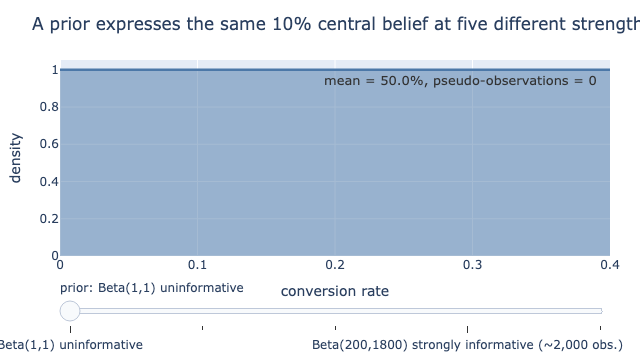

In [9]:
fig = FIGURES["chapter-05-fig-beta-prior-shapes"]()
fig

**`chapter-05-fig-posterior-update`**

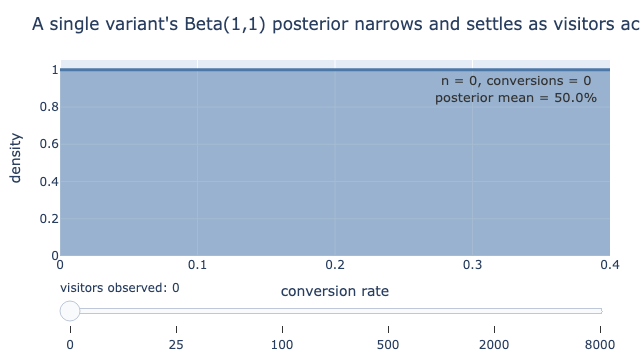

In [10]:
fig = FIGURES["chapter-05-fig-posterior-update"]()
fig

**`chapter-05-fig-posteriors-ab-overlay`**

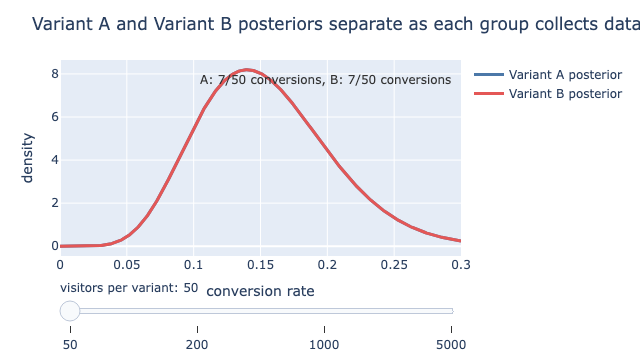

In [11]:
fig = FIGURES["chapter-05-fig-posteriors-ab-overlay"]()
fig

**`chapter-05-fig-decision-metrics`**

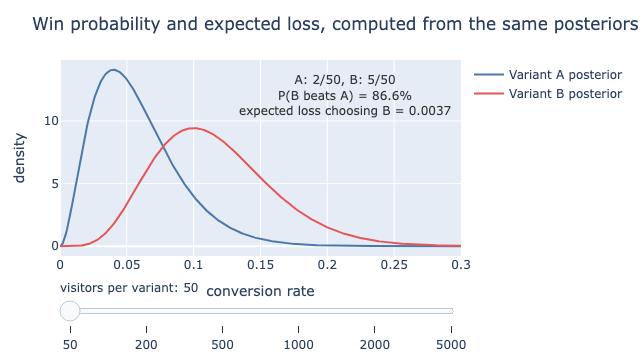

In [12]:
fig = FIGURES["chapter-05-fig-decision-metrics"]()
fig

**`chapter-05-fig-peeking-problem`**

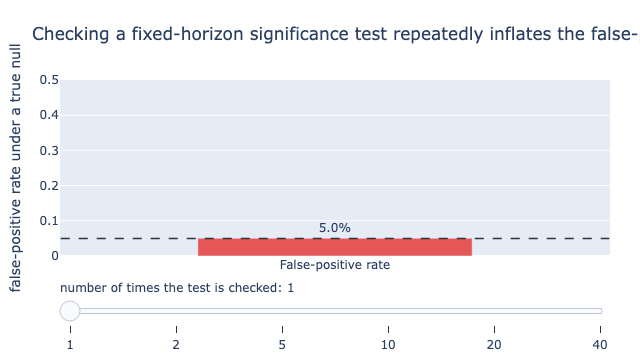

In [13]:
fig = FIGURES["chapter-05-fig-peeking-problem"]()
fig